## This project simulates a real-world data analyst workflow for
## MetroMove Transit Solutions, a multi-city public transportation provider operating buses, trains, ferries, and trams.


## The pipeline covers:

## Exploratory Data Analysis (EDA) — profiling a messy, real-world-style dataset
## Data Cleaning — resolving inconsistencies across transport modes, station names, and missing values
## KPI Extraction — computing operational metrics across 10 data fields
## Automated Reporting — generating a fully-designed 11-slide PowerPoint deck using pptxgenjs

In [5]:
# Import libraries

import  pandas as pd   #dataframes for working with tabular data
import numpy  as np  # numerical operations

#visulization
import matplotlib.pyplot as plt 
import seaborn as sns

#scikit learn  machine learning 
# Machine preprocessing 
from sklearn.model_selection import train_test_split   # split data into train/test sets
from sklearn.preprocessing import StandardScaler  # standardize numerical features / columns
from sklearn.preprocessing import LabelEncoder  # Encode categorical columns


#machine learning Model 
from sklearn.linear_model import LogisticRegression 
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier 


# Machine Learning Evaluation

from sklearn.metrics import (accuracy_score, 
                               precision_score, 
                               recall_score, 
                               f1_score, 
                               confusion_matrix,
                               classification_report, 
                               roc_auc_score,
                               roc_curve)

#Setting
import warnings
warnings.filterwarnings('ignore')

sns.set_style ('whitegrid')
plt.rcParams['figure.figsize'] = (10,6)

#Set random seed for reproducility

RANDOM_STATE = 42

print("All libraries imported successfully!")

All libraries imported successfully!


# loading csv_file


In [43]:
#uploading the csv file

DATA_CAPSTONE= "Public_Transport_Trips_EDA.xlsx - Sheet1.csv"

df = pd.read_csv(DATA_CAPSTONE)
print(f"data loaded successfully!")
print(f"shape: {df.shape[0]:} row x {df.shape[1]} columns")
print(f" data loaded successfully")

data loaded successfully!
shape: 1000 row x 12 columns
 data loaded successfully


In [44]:
#checking the first columns of tr data
print("first five head")
df.head()

first five head


,Trip_ID,Mode_of_Transport,Departure_Station,Arrival_Station,Departure_Time,Passenger_Count,Fare_Amount,Trip_Duration_Minutes,Trip_Date,Day_of_Week,Unnamed: 10,Unnamed: 11
0,TRIP0001,FERRY,West End,airport,2024-01-01 06:00:00,21.0,4.343642,26.0,2024-01-01,Sunday,NaN,F
1,TRIP0002,Tram,North Station,Downtown,2024-01-01 06:01:00,46.0,20.673380,134.0,2024-01-01,Saturday,NaN,F
2,TRIP0003,bus,Central,North Station,2024-01-01 06:02:00,91.0,NaN,NaN,2024-01-01,Tuesday,NaN,F
3,TRIP0004,FERRY,Downtown,Central,2024-01-01 06:03:00,27.0,3.767487,NaN,2024-01-01,Sunday,NaN,F
4,TRIP0005,Ferry,Downtown,Central,2024-01-01 06:04:00,66.0,NaN,NaN,2024-01-01,Monday,NaN,F


In [26]:
df.duplicated().sum()

np.int64(0)

 ### checking for outliers

In [27]:
numerical_columns = df.select_dtypes(include="number")
print(len(numerical_columns.columns))

7


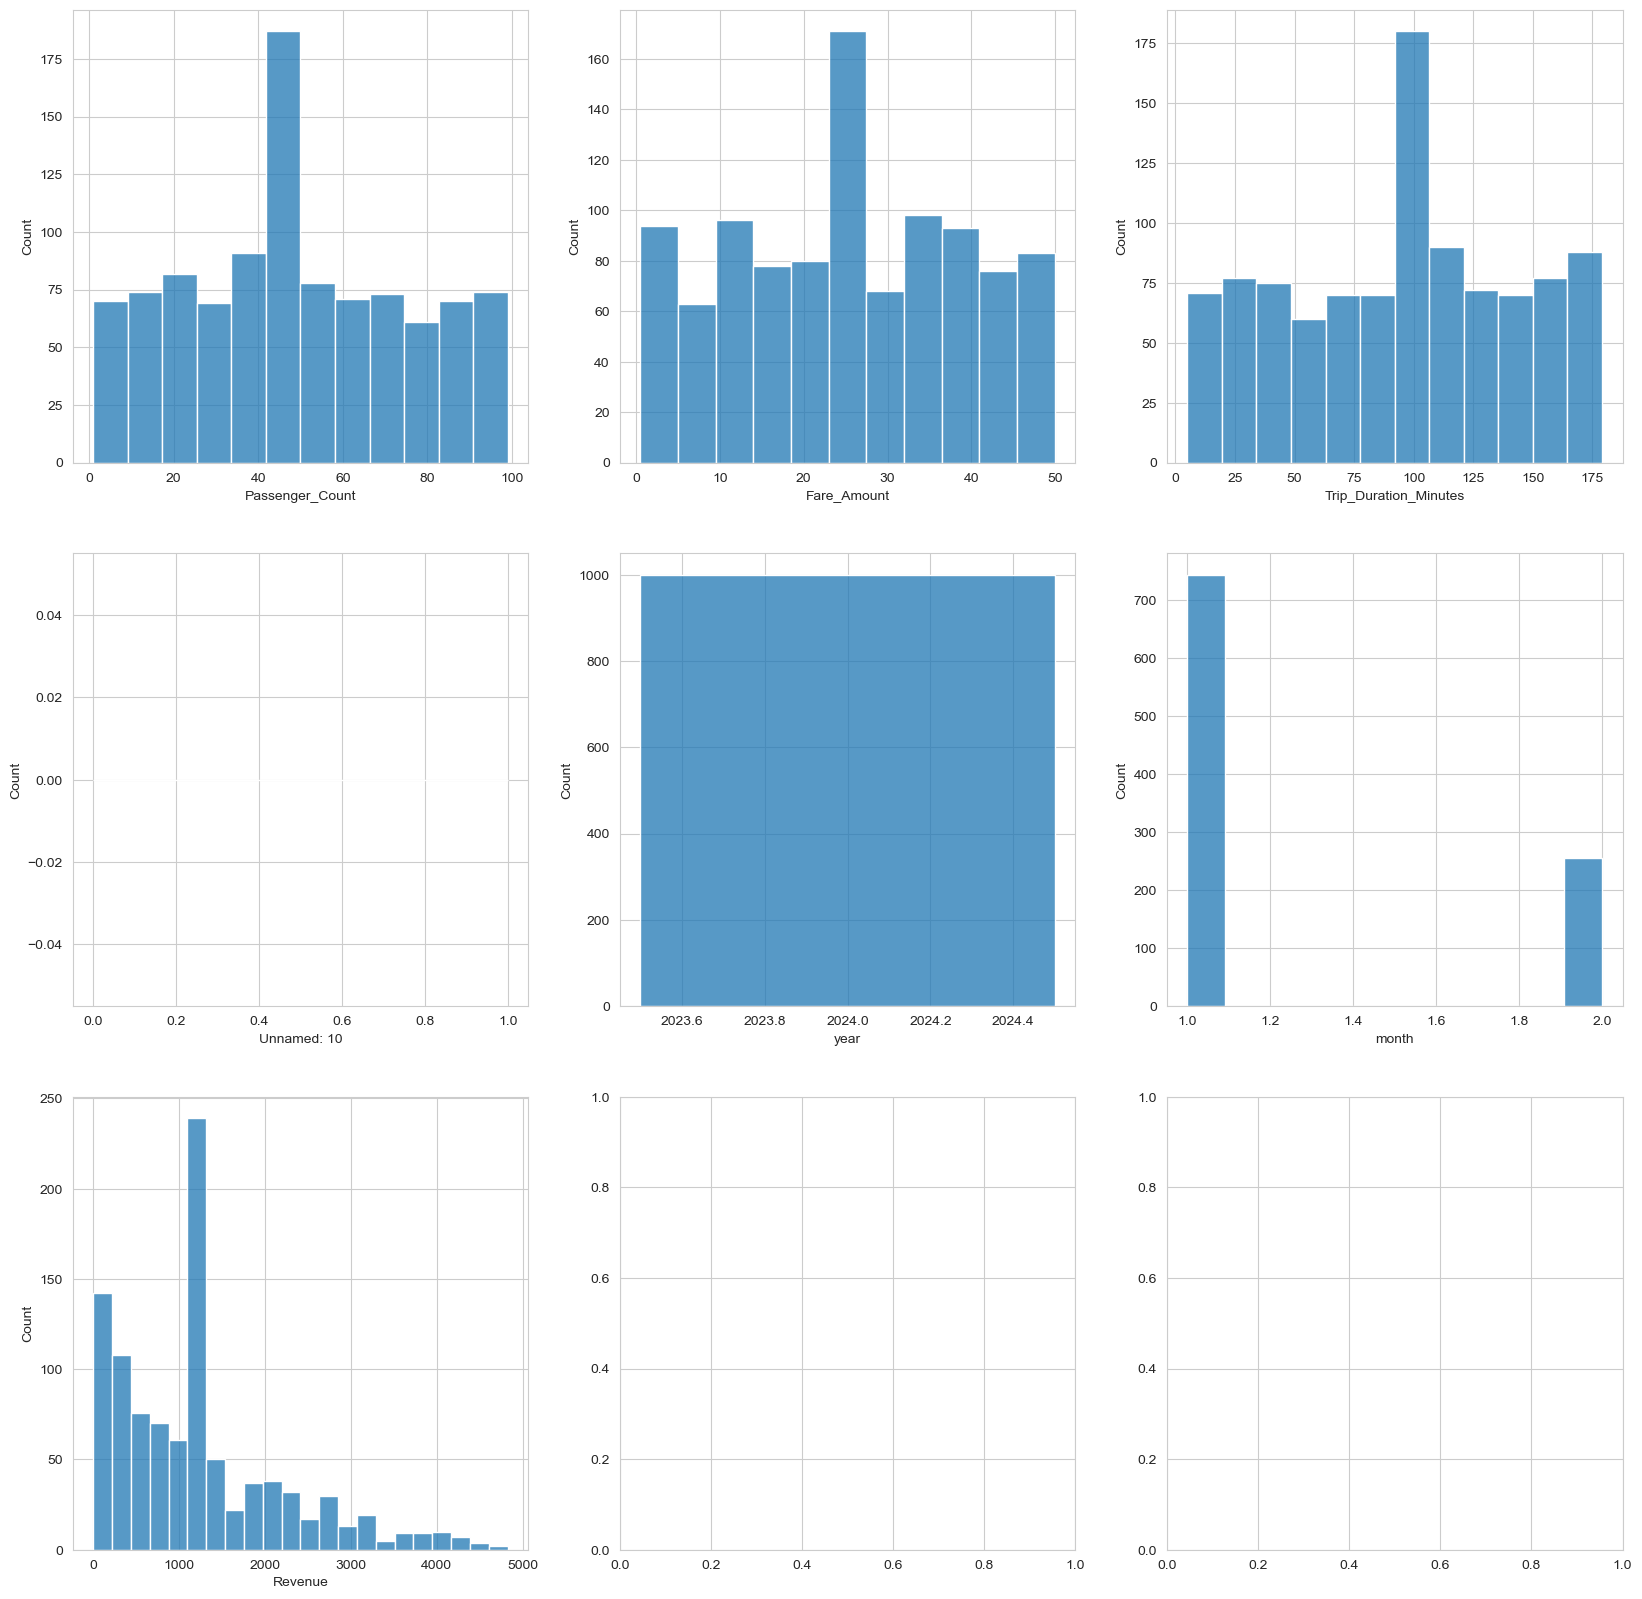

In [33]:
fig, ax = plt.subplots(nrows=3,ncols=3, figsize=(20,20))
ax = ax.flatten()
for nk, col in enumerate(numerical_columns):
    sns.histplot(df[col], ax=ax[nk])
plt.show()

In [37]:
df = df.drop(columns=["Unnamed: 10", "Unnamed: 11"])

In [38]:
df["Trip_Date"] = pd.to_datetime(df["Trip_Date"])
df["Departure_Time"] = pd.to_datetime(df["Departure_Time"])

df["year"] = df["Trip_Date"].dt.year
df["month"] = df["Trip_Date"].dt.month
df["Revenue"] = df["Passenger_Count"]*df["Fare_Amount"]

In [17]:
print(df["Trip_Duration_Minutes"].dtype)

float64


## Trip grouping

In [39]:
df["Trip_Duration_Minutes"] = pd.to_numeric(df["Trip_Duration_Minutes"], errors="coerce")

def trip_type(x):
    if x <= 50:
        return "<=50 very short trip"
    elif x <= 100:
        return "51-100 short trip"
    else:
        return ">=101 long trip"

df["trip_type"] = df["Trip_Duration_Minutes"].apply(trip_type)

In [ ]:
## a while

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Trip_ID                1000 non-null   object        
 1   Mode_of_Transport      1000 non-null   object        
 2   Departure_Station      1000 non-null   object        
 3   Arrival_Station        1000 non-null   object        
 4   Departure_Time         1000 non-null   datetime64[ns]
 5   Passenger_Count        1000 non-null   float64       
 6   Fare_Amount            1000 non-null   float64       
 7   Trip_Duration_Minutes  1000 non-null   float64       
 8   Trip_Date              1000 non-null   datetime64[ns]
 9   Day_of_Week            1000 non-null   object        
 10  year                   1000 non-null   int32         
 11  month                  1000 non-null   int32         
 12  Revenue                1000 non-null   float64       
 13  trip

In [41]:
isnull_vals = df.isnull(). sum()
isnull_vals

Trip_ID                  0
Mode_of_Transport        0
Departure_Station        0
Arrival_Station          0
Departure_Time           0
Passenger_Count          0
Fare_Amount              0
Trip_Duration_Minutes    0
Trip_Date                0
Day_of_Week              0
year                     0
month                    0
Revenue                  0
trip_type                0
dtype: int64

## handling missing data

In [42]:
df["Trip_Duration_Minutes"].fillna(df["Trip_Duration_Minutes"].mean(), inplace=True)

df["Passenger_Count"].fillna(df["Passenger_Count"].mean(), inplace=True)

df["Fare_Amount"].fillna(df["Fare_Amount"].mean(), inplace=True)
df["Revenue"].fillna(df["Revenue"].mean(), inplace=True)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Trip_ID                1000 non-null   object        
 1   Mode_of_Transport      1000 non-null   object        
 2   Departure_Station      1000 non-null   object        
 3   Arrival_Station        1000 non-null   object        
 4   Departure_Time         1000 non-null   datetime64[ns]
 5   Passenger_Count        1000 non-null   float64       
 6   Fare_Amount            1000 non-null   float64       
 7   Trip_Duration_Minutes  1000 non-null   float64       
 8   Trip_Date              1000 non-null   datetime64[ns]
 9   Day_of_Week            1000 non-null   object        
 10  Unnamed: 10            0 non-null      float64       
 11  Unnamed: 11            299 non-null    object        
 12  year                   1000 non-null   int32         
 13  mont

In [15]:
##descriptive analysis
df.describe()

,Departure_Time,Passenger_Count,Fare_Amount,Trip_Duration_Minutes,Trip_Date,Unnamed: 10,year,month,Revenue
count,1000,1000.000000,1000.000000,1000.000000,1000,0.0,1000.0,1000.00000,1000.000000
mean,2024-01-01 14:19:30,49.154444,25.360742,94.270000,2024-01-21 08:03:50.400000,NaN,2024.0,1.25600,1237.559199
min,2024-01-01 06:00:00,1.000000,0.500576,5.000000,2024-01-01 00:00:00,NaN,2024.0,1.00000,4.191420
25%,2024-01-01 10:09:45,28.000000,13.917364,55.000000,2024-01-11 00:00:00,NaN,2024.0,1.00000,442.229365
50%,2024-01-01 14:19:30,49.154444,25.360742,94.270000,2024-01-21 00:00:00,NaN,2024.0,1.00000,1237.559199
75%,2024-01-01 18:29:15,70.000000,36.580122,132.250000,2024-02-01 00:00:00,NaN,2024.0,2.00000,1572.565637
max,2024-01-01 22:39:00,99.000000,49.945184,179.000000,2024-02-11 00:00:00,NaN,2024.0,2.00000,4826.548112
std,NaN,26.275424,13.721520,48.033891,NaN,NaN,0.0,0.43664,984.359754


In [16]:
df.loc[df["Mode_of_Transport"] == "FERRY", "Mode_of_Transport"] = "Ferry"
df.loc[df["Mode_of_Transport"] == "fErry", "Mode_of_Transport"] = "Ferry"
df.loc[df["Mode_of_Transport"] == "ferry", "Mode_of_Transport"] = "Ferry"
df.loc[df["Mode_of_Transport"] == "BUS", "Mode_of_Transport"] = "Bus"
df.loc[df["Mode_of_Transport"] == "bus", "Mode_of_Transport"] = "Bus"
df.loc[df["Mode_of_Transport"] == "Train", "Mode_of_Transport"] = "train"


<Axes: xlabel='Mode_of_Transport', ylabel='count'>

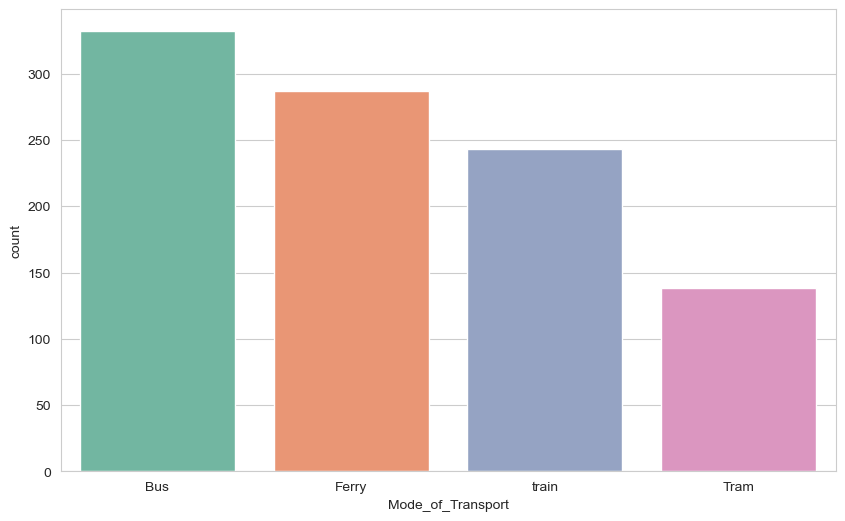

In [17]:
sns.countplot(
    x="Mode_of_Transport",
    data=df,
    order=df["Mode_of_Transport"].value_counts().index,    palette="Set2"
)

In [18]:
df["Departure_Station"] = df["Departure_Station"].str.strip()

df.loc[df["Departure_Station"].str.lower() == "Central", "Departure_Station"] = "central"
df.loc[df["Departure_Station"].str.lower() == "airport", "Departure_Station"] = "airport"

<Axes: xlabel='Departure_Station', ylabel='count'>

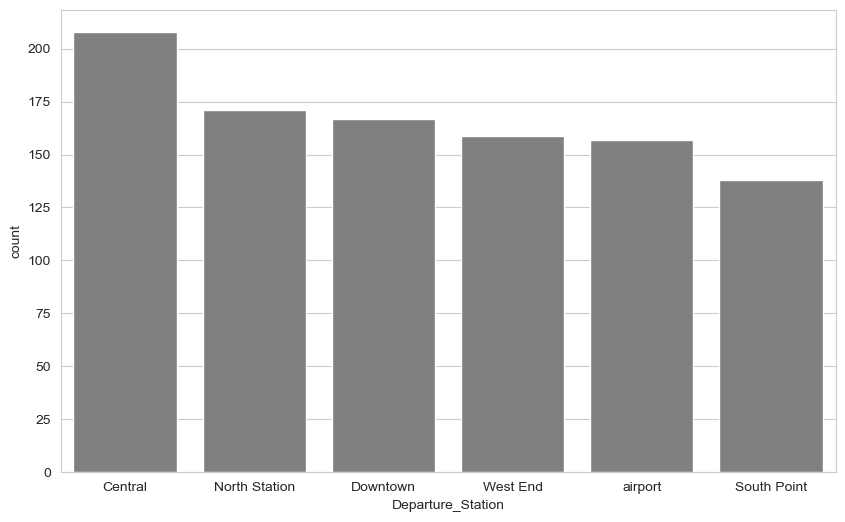

In [31]:
sns.countplot(
    x="Departure_Station",
    data=df,
    order=df["Departure_Station"].value_counts().index, color="grey")

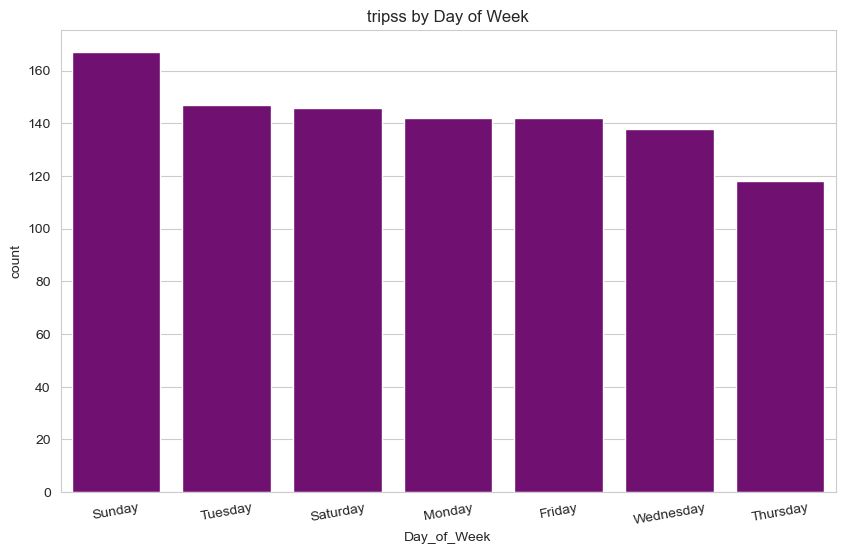

In [22]:
sns.countplot(
    x="Day_of_Week",
    data=df,
    order=df["Day_of_Week"].value_counts().index,
    color="purple"
)

plt.title("tripss by Day of Week")
plt.xticks(rotation=10)
plt.show()

In [20]:
df.loc[df["Arrival_Station"].str.lower() == "airport", "Arrival_Station"] = "airport"

In [21]:
df.loc[df["Arrival_Station"].str.lower() == "airport", "Arrival_Station"] = "airport"

<Axes: xlabel='Arrival_Station', ylabel='count'>

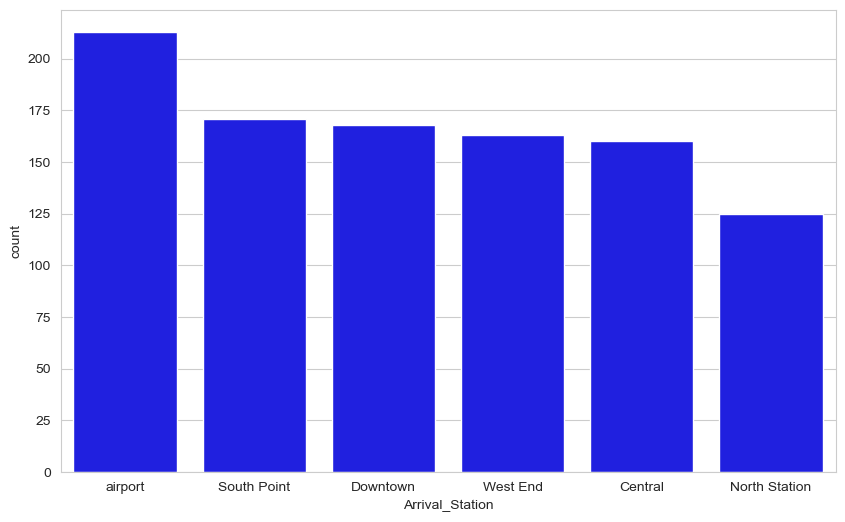

In [22]:
sns.countplot(
    x="Arrival_Station",
    data=df,
    order=df["Arrival_Station"].value_counts().index, color="blue")

In [23]:
avg_passengers = df["Passenger_Count"]. mean()
print(avg_passengers)

49.15444444444444


In [24]:
avg_passengers = df.groupby("Mode_of_Transport")["Passenger_Count"].mean()
print(avg_passengers)

Mode_of_Transport
Bus      49.133507
Ferry    49.940283
Tram     50.986683
train    47.214390
Name: Passenger_Count, dtype: float64


In [25]:
avg_minutes = df["Trip_Duration_Minutes"]. mean()
print(avg_minutes)

94.27


In [26]:
avg_amount = df["Fare_Amount"]. mean()
print(avg_amount)

25.36074194499122


In [27]:
avg_amount = df.groupby("Mode_of_Transport")["Fare_Amount"].mean()
print(avg_amount)

Mode_of_Transport
Bus      25.595263
Ferry    24.472627
Tram     25.251043
train    26.151551
Name: Fare_Amount, dtype: float64


In [28]:
trip_count = df.groupby("Mode_of_Transport")["Trip_ID"].count()
print(trip_count)

Mode_of_Transport
Bus      332
Ferry    287
Tram     138
train    243
Name: Trip_ID, dtype: int64


In [30]:
trip_count = df.groupby("Departure_Station")["Trip_ID"].count()
print(trip_count)

Departure_Station
Central          208
Downtown         167
North Station    171
South Point      138
West End         159
airport          157
Name: Trip_ID, dtype: int64


In [34]:
trip_count = df.groupby("Day_of_Week")["Departure_Station"].count()
print(trip_count)

Day_of_Week
Friday       142
Monday       142
Saturday     146
Sunday       167
Thursday     118
Tuesday      147
Wednesday    138
Name: Departure_Station, dtype: int64


In [35]:
trip_count = df.groupby("Day_of_Week")["Arrival_Station"].count()
print(trip_count)

Day_of_Week
Friday       142
Monday       142
Saturday     146
Sunday       167
Thursday     118
Tuesday      147
Wednesday    138
Name: Arrival_Station, dtype: int64


In [ ]:
trip_count = df.groupby("Day_of_Week")["Trip_ID"].count()
print(trip_count)

In [235]:
trip_count = df["Day_of_Week"].value_counts()
print(trip_count)

Day_of_Week
Sunday       167
Tuesday      147
Saturday     146
Monday       142
Friday       142
Wednesday    138
Thursday     118
Name: count, dtype: int64


In [201]:
#total trips
total_trips = df["Trip_ID"].count()
print(total_trips)

1000


In [188]:
trans_perf = df.groupby("Mode_of_Transport")["Trip_Duration_Minutes"].sum().reset_index()
trans_perf


,Mode_of_Transport,Trip_Duration_Minutes
0,Bus,31877.91
1,Ferry,26356.02
2,Tram,13106.59
3,train,22929.48


In [236]:
trans_perf = df.groupby("Mode_of_Transport")["Trip_Duration_Minutes"].mean().reset_index()
trans_perf


,Mode_of_Transport,Trip_Duration_Minutes
0,Bus,96.017801
1,Ferry,91.832822
2,Tram,94.975290
3,train,94.360000


Bus: 332 (33.2%)
Ferry: 287 (28.7%)
train: 243 (24.3%)
Tram: 138 (13.8%)


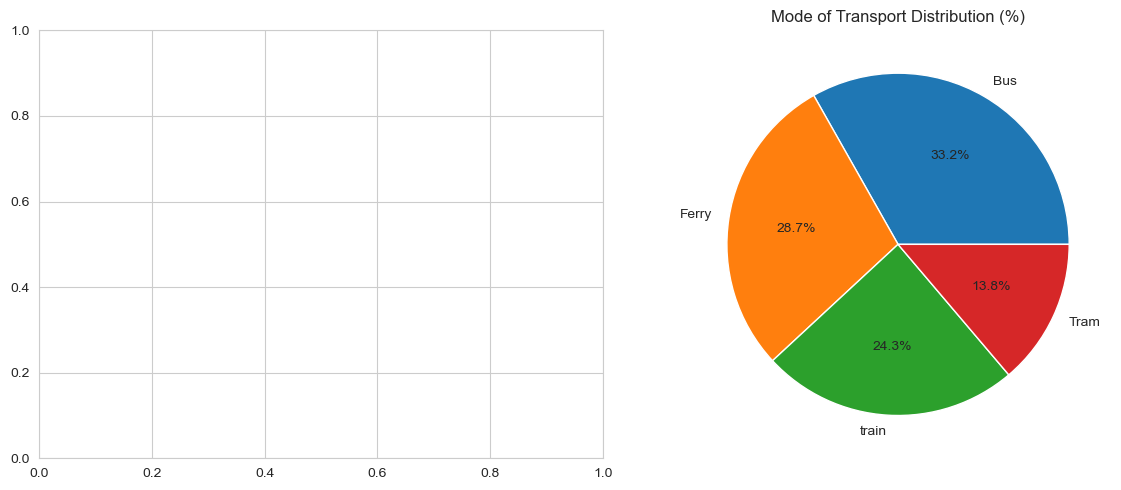

In [189]:
target_counts = df['Mode_of_Transport'].value_counts()
target_pct = df['Mode_of_Transport'].value_counts(normalize=True) * 100

# Print results dynamically
for val in target_counts.index:
    print(f"{val}: {target_counts[val]:,} ({target_pct[val]:.1f}%)")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart
axes[1].pie(target_counts.values,
            labels=target_counts.index.astype(str),
            autopct='%1.1f%%')
axes[1].set_title('Mode of Transport Distribution (%)')

plt.tight_layout()
plt.show()

<Axes: xlabel='trip_type', ylabel='count'>

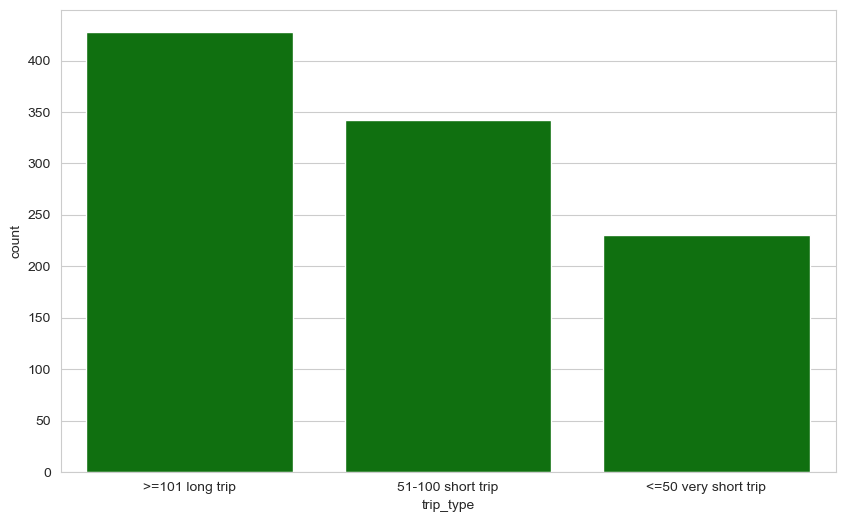

In [213]:
sns.countplot(
    x="trip_type",
    data=df,
    order=df["trip_type"].value_counts().index,
    color="green")

Text(0.5, 1.0, 'trip_type and customer ')

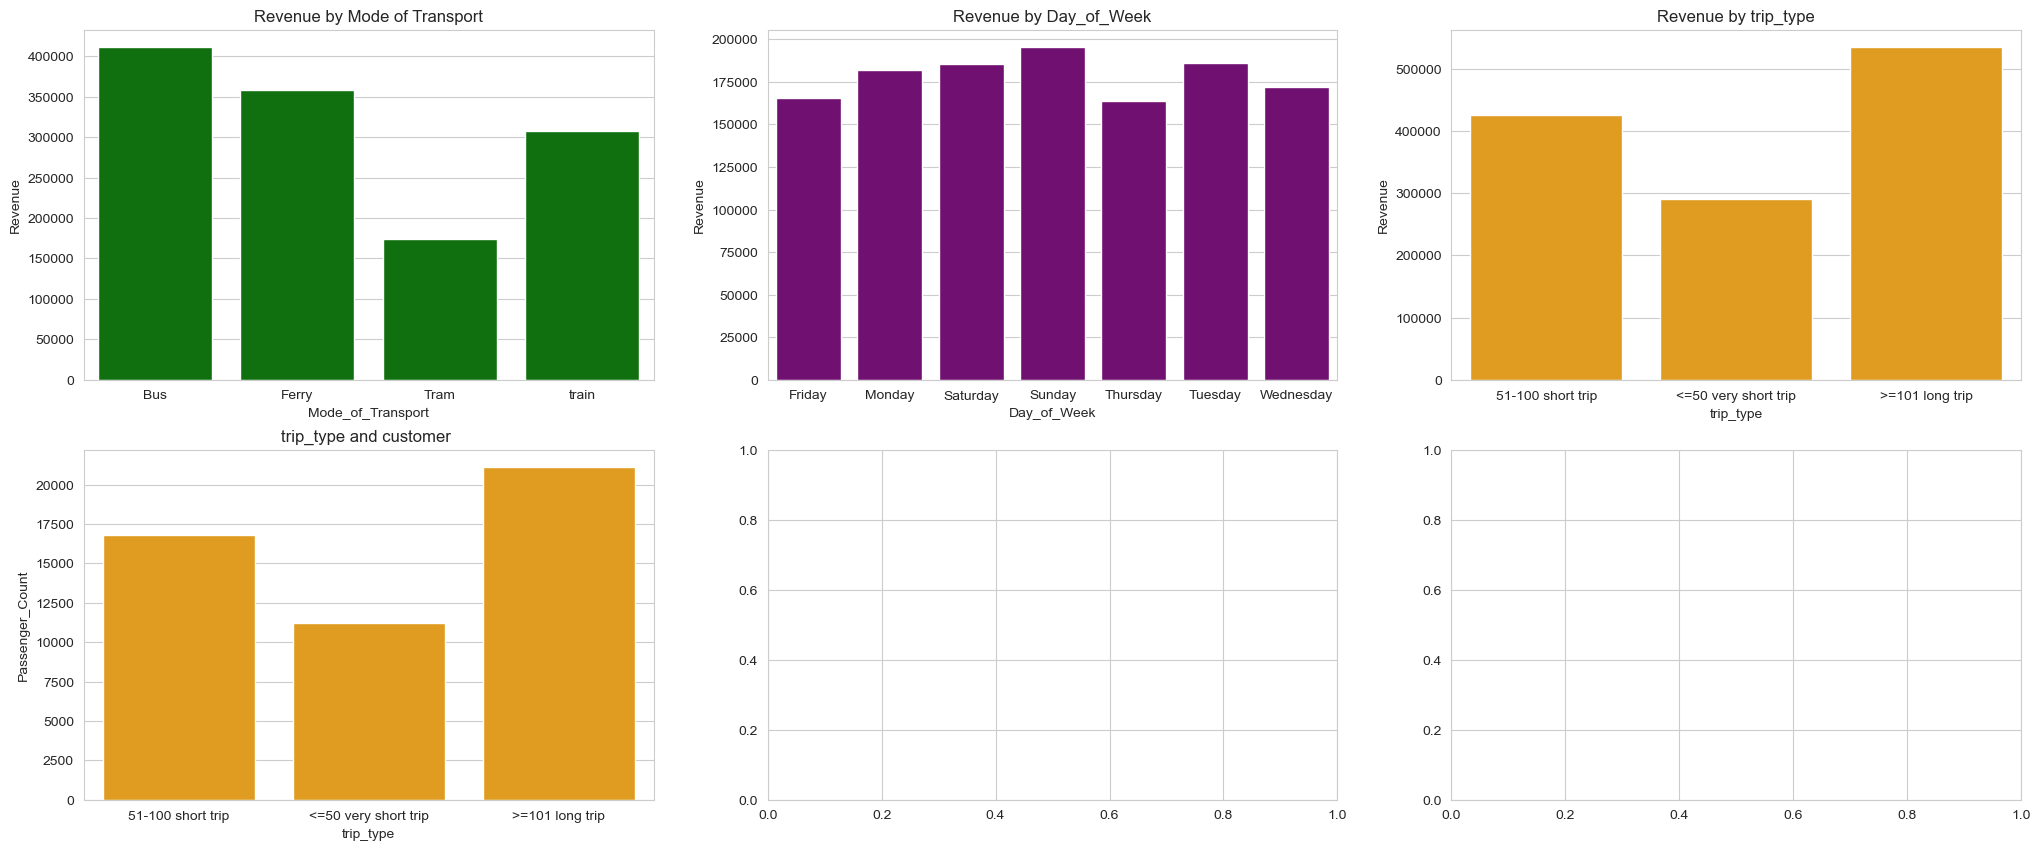

In [223]:
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(25,10))
#revenue by mode of transportation
Days_perf = df.groupby("Mode_of_Transport")["Revenue"].sum().reset_index()

sns.barplot(x="Mode_of_Transport",y="Revenue",data=Days_perf,ax=axs[0,0],color="green")  
axs[0,0].set_title("Revenue by Mode of Transport")
            
# 2 Revenue_by _the of the week
Days_perf = df.groupby("Day_of_Week")["Revenue"].sum().reset_index()
sns.barplot(x="Day_of_Week", data=Days_perf,   y="Revenue", ax=axs[0,1],color= "purple")
axs[0,1].set_title("Revenue by Day_of_Week")

# 3 Revenue by Trip_type
trans_perf = df.groupby("trip_type")["Revenue"].sum().reset_index()
sns.barplot(x="trip_type", data=trans_perf,   y="Revenue", ax=axs[0,2],color="orange")
axs[0,2].set_title("Revenue by trip_type")
# passsenger count by trip type
trans_perf = df.groupby("trip_type")["Passenger_Count"].sum().reset_index()
sns.barplot(x="trip_type", data=trans_perf,   y="Passenger_Count", ax=axs[1,0],color="orange")
axs[1,0].set_title("trip_type and customer ")


## numerical variable


In [173]:
procat = df.groupby(["Mode_of_Transport", "trip_type"]).agg(
    total_revenue=("Revenue", "sum"),
    trip_count=("Revenue", "count")
).reset_index()

In [131]:
print(f"Number of rows (Trip_ID): {df.shape[0]:}")
print(f"number of columns (features + target ): {df.shape[1]}")
print()

Number of rows (Trip_ID): 1000
number of columns (features + target ): 16



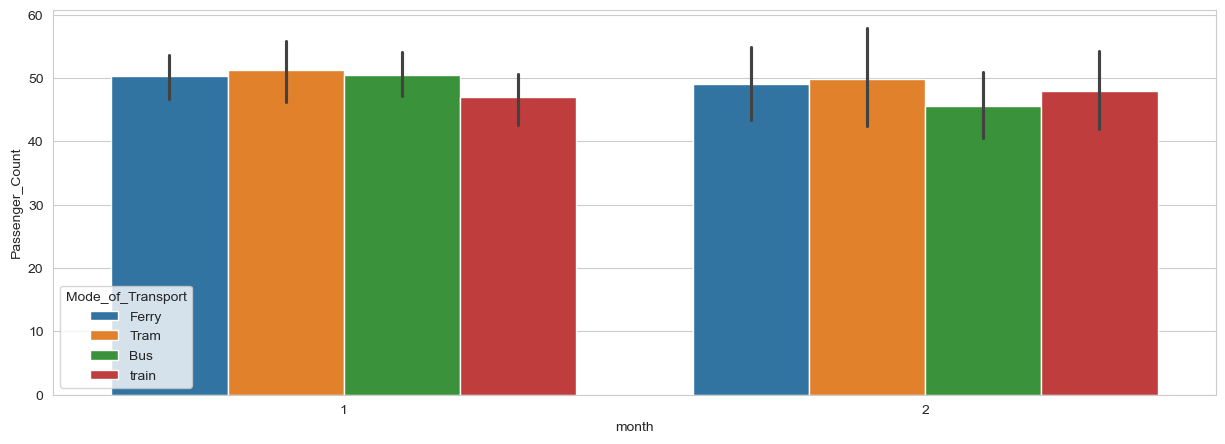

In [202]:
###### Using Multivariante to visualize the passenger count on different mode of transport across each month

plt.figure(figsize=(15,5))

sns.barplot(x="month", y='Passenger_Count', data=df, hue="Mode_of_Transport");

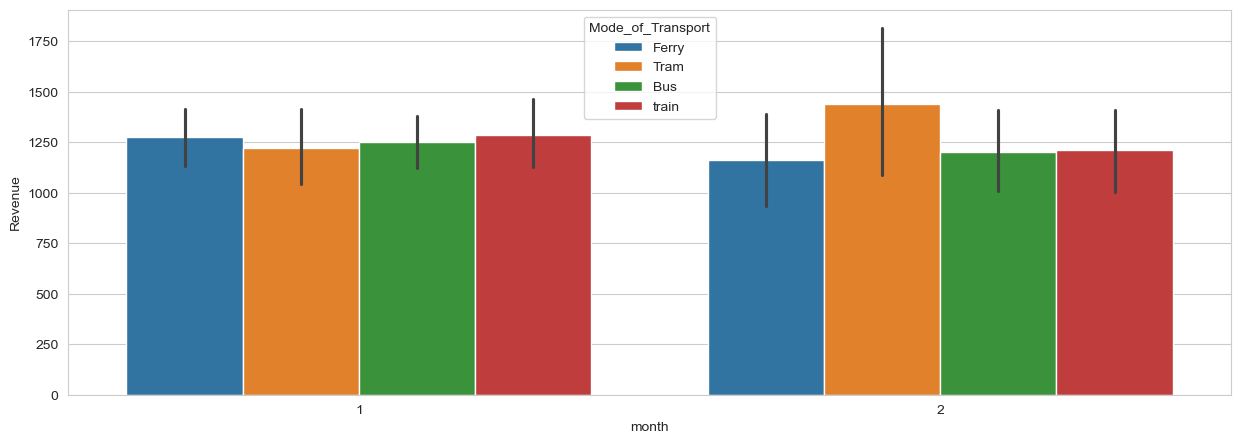

In [226]:
####### Using Multivariante to visualize the revenue generated on different mode of transport across each month

plt.figure(figsize=(15,5))

sns.barplot(x="month", y='Revenue', data=df, hue="Mode_of_Transport");